<h1><center>TYPE 1 - TRAINING MODEL WITHOUT REDUCING THE DIMENSION</h1></center>

<h3>STEP 1 - Load Libraries</h3>

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

from tcn import TCN

<h3>STEP 2 - Loading Dataset</h3>

In [ ]:
import pandas as pd

data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')
X = data.drop("Encoded_Label", axis=1)
y = data["Encoded_Label"]

print("Dataset Shape: ", data.shape)

Dataset Shape:  (2520751, 81)


<h3>STEP 3 - Scaling</h3>

In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\tcn\tcn_scaler.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 4 - Train / Validation / Test Split</h3>

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

<h3>STEP 5 - Compute Class Weights</h3>

In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

class_weights_dict = {
    k: min(v, 30)
    for k, v in class_weights_dict.items()
}

<h3>STEP 6 - Reshape for Sequence Input</h3>

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

<h3>STEP 7 - Build TCN Model</h3>

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([

    Input(shape=(79,1)),

    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1,2,4,8],
        dropout_rate=0.2,
        return_sequences=False
    ),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(7, activation='softmax')
])

<h3>STEP 8 - Compile</h3>

In [12]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │        86,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,463 (357.28 KB)

 Trainable params: 91,463 (357.28 KB)

 Non-trainable params: 0 (0.00 B)

<h3>STEP 11 - Training Callbacks</h3>

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

<h3>STEP 12 - Train Model</h3>

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 104s 52ms/step - accuracy: 0.6134 - loss: 0.8028 - val_accuracy: 0.8664 - val_loss: 0.4519 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 84s 49ms/step - accuracy: 0.8546 - loss: 0.1780 - val_accuracy: 0.8691 - val_loss: 0.3347 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 85s 49ms/step - accuracy: 0.8827 - loss: 0.1193 - val_accuracy: 0.8940 - val_loss: 0.2591 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.8989 - loss: 0.0981 - val_accuracy: 0.9006 - val_loss: 0.2382 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.9027 - loss: 0.0864 - val_accuracy: 0.8851 - val_loss: 0.2303 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.9062 - loss: 0.0793 - val_accuracy: 0.8977 - val_loss: 0.2053 - learning_rate: 5.0000e-04
Epoch 7/15
1724/1724 ━━━━━━━━━━━━━━━━━━

<h3>STEP 13 - Evaluation</h3>

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9228 - loss: 0.1603
Test Accuracy: 0.9231076240539551


In [16]:
y_pred = model.predict(X_test, batch_size=1024)

y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
              precision    recall  f1-score   support

           0     0.9995    0.9083    0.9517    314259
           1     0.0297    1.0000    0.0577       292
           2     0.6196    0.9658    0.7549      1373
           3     0.8294    0.9993    0.9064     19202
           4     0.7780    0.9957    0.8735     29062
           5     0.7346    0.9968    0.8459     13604
           6     0.1690    0.9439    0.2867       321

    accuracy                         0.9231    378113
   macro avg     0.5943    0.9728    0.6681    378113
weighted avg     0.9615    0.9231    0.9376    378113



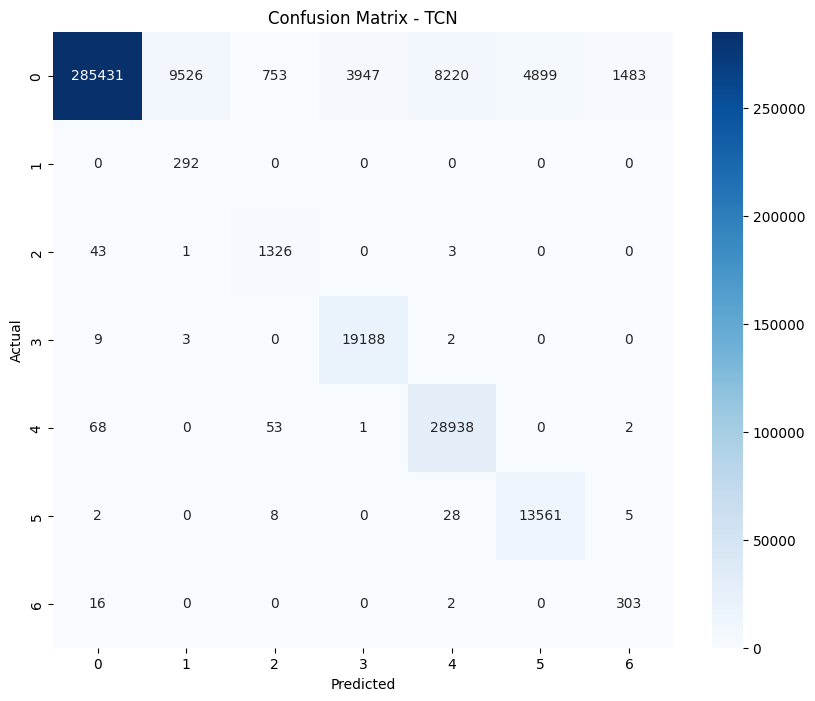

In [17]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.title("Confusion Matrix - TCN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# Save in legacy HDF5 format
# model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\tcn\tcn_model.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\tcn\tcn_model.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.


<h1><center>TYPE 2 - TRAINING MODEL WITH SELECTED TOP 35 FEATURES</h1></center>

<h3>STEP 1 - Loading Dataset</h3>

In [ ]:
import pandas as pd

data_top_sec = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_04\cicids2017_selected_top_features.csv')

X = data_top_sec.drop("Encoded_Label", axis=1)
y = data_top_sec["Encoded_Label"]

print("Dataset Shape: ", data_top_sec.shape)

Dataset Shape:  (2520751, 36)


<h3>STEP 2 - Scaling</h3>

In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\tcn\tcn_scaler_top_selected.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 3 - Train / Test / Validation</h3>

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

class_weights_dict = {
    k: min(v, 30)
    for k, v in class_weights_dict.items()
}

In [24]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([

    Input(shape=(35,1)),

    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1,2,4,8],
        dropout_rate=0.2,
        return_sequences=False
    ),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(7, activation='softmax')
])

In [26]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_1 (TCN)                     │ (None, 64)             │        86,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,463 (357.28 KB)

 Trainable params: 91,463 (357.28 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 65s 31ms/step - accuracy: 0.6973 - loss: 0.7336 - val_accuracy: 0.9005 - val_loss: 0.3222 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.8943 - loss: 0.1409 - val_accuracy: 0.9162 - val_loss: 0.2424 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9178 - loss: 0.0885 - val_accuracy: 0.9219 - val_loss: 0.1985 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9250 - loss: 0.0733 - val_accuracy: 0.9305 - val_loss: 0.1720 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9314 - loss: 0.0633 - val_accuracy: 0.9283 - val_loss: 0.1777 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9338 - loss: 0.0598 - val_accuracy: 0.9335 - val_loss: 0.1548 - learning_rate: 5.0000e-04
Epoch 7/15
1724/1724 ━━━━━━━━━━━━━━━━━━━

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9496 - loss: 0.1128
Test Accuracy: 0.949874758720398


In [30]:
y_pred = model.predict(X_test, batch_size=1024)

y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
              precision    recall  f1-score   support

           0     0.9999    0.9402    0.9691    314259
           1     0.0453    0.9966    0.0867       292
           2     0.5746    0.9956    0.7287      1373
           3     0.9408    0.9994    0.9692     19202
           4     0.8790    0.9966    0.9341     29062
           5     0.7387    0.9987    0.8492     13604
           6     0.1466    0.9564    0.2542       321

    accuracy                         0.9499    378113
   macro avg     0.6179    0.9834    0.6845    378113
weighted avg     0.9752    0.9499    0.9600    378113



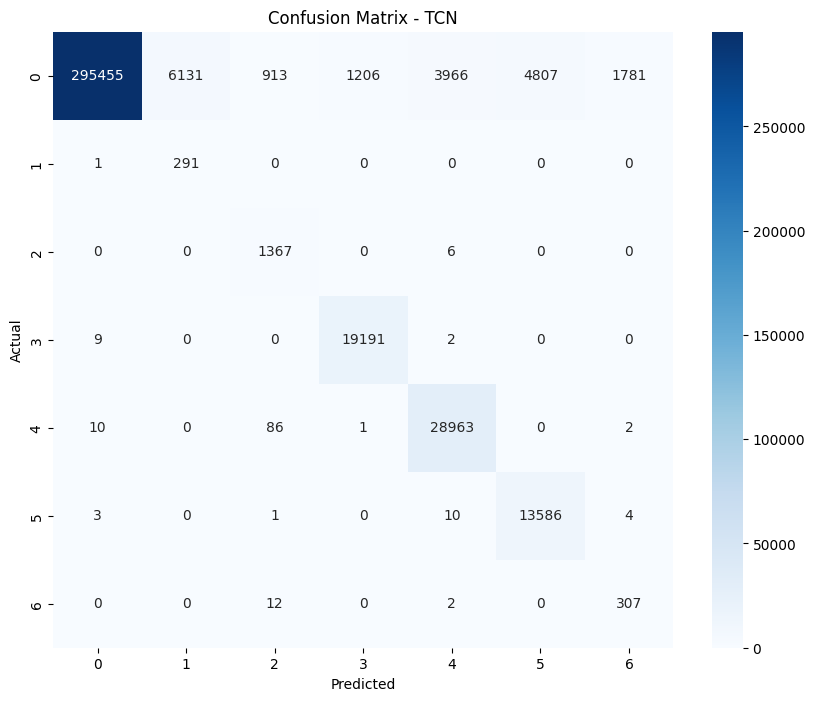

In [31]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.title("Confusion Matrix - TCN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
# Save in legacy HDF5 format
# model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\tcn\tcn_model_top_selected.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\tcn\tcn_model_top_selected.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.
